In [37]:
%pip install -q pandas scikit-learn scipy matplotlib


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import specific tools for hierarchical and density-based clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Configure pandas to show more columns and cleaner numbers
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)

# Set a clean visual style for our plots
plt.style.use("seaborn-v0_8-whitegrid")

def plot_cluster_map(points_2d, labels, title, axis=None, x_label="Component 1", y_label="Component 2"):
    """Helper to visualize 2D clusters with distinct colors for each group and black for noise."""
    if axis is None:
        axis = plt.gca()

    unique_labels = sorted(np.unique(labels))
    palette = plt.get_cmap("tab10")
    color_index = 0

    for label in unique_labels:
        mask = labels == label
        if label == -1:
            # Handle noise points specifically for DBSCAN
            axis.scatter(points_2d[mask, 0], points_2d[mask, 1], color="black", s=45, alpha=0.85, label="noise")
        else:
            # Plot standard clusters
            axis.scatter(points_2d[mask, 0], points_2d[mask, 1], color=palette(color_index % 10), s=45, alpha=0.85, label=f"cluster {label}")
            color_index += 1

    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.legend()
    axis.grid(alpha=0.25)

def silhouette_details(features, labels):
    """Calculates how well-separated the clusters are."""
    unique_labels = np.unique(labels)
    # We need at least 2 clusters (and not just noise) to compute a meaningful score
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return np.full(len(labels), np.nan), np.nan

    sample_scores = silhouette_samples(features, labels)
    average_score = silhouette_score(features, labels)
    return sample_scores, float(average_score)

def describe_clustering(features, labels, model_name):
    """Summarizes the results of a clustering run into a dictionary."""
    sample_scores, average_score = silhouette_details(features, labels)
    row = {
        "model": model_name,
        "cluster_count": int(len(set(labels)) - (1 if -1 in labels else 0)),
        "noise_points": int(np.sum(labels == -1)),
        "silhouette_score": average_score,
    }
    return row, sample_scores

def estimate_eps_from_k_distance(sorted_distances):
    """Finds the 'elbow' point in the K-distance graph to suggest an optimal eps for DBSCAN."""
    x_values = np.arange(len(sorted_distances), dtype=float)
    points = np.column_stack((x_values, sorted_distances))
    start, end = points[0], points[-1]

    # Calculate the distance of every point to the line connecting start and end
    line_vector = (end - start) / np.linalg.norm(end - start)
    projected_points = start + np.outer((points - start) @ line_vector, line_vector)
    distances_to_line = np.linalg.norm(points - projected_points, axis=1)

    # The point furthest from the straight line is our 'elbow'
    elbow_index = int(np.argmax(distances_to_line))
    return float(sorted_distances[elbow_index]), elbow_index

In [39]:
from sklearn.datasets import make_blobs

# Create a dummy dataset with 4 distinct groups to test our algorithms
X_syn, y_syn = make_blobs(
    n_samples=[120, 110, 130, 90],
    centers=[(-7, -2), (-1, 4.5), (4.5, -4), (7, 4)],
    cluster_std=[1.0, 0.8, 1.1, 0.7],
    random_state=42,
)

syn_df = pd.DataFrame(X_syn, columns=["feature_1", "feature_2"])
print("Synthetic dataset shape:", X_syn.shape)
display(syn_df.head())

Synthetic dataset shape: (450, 2)


,feature_1,feature_2
0,6.5626,4.0183
1,-6.4850,-1.4862
2,4.6093,-3.1735
3,6.5710,3.7286
4,7.4954,3.6063


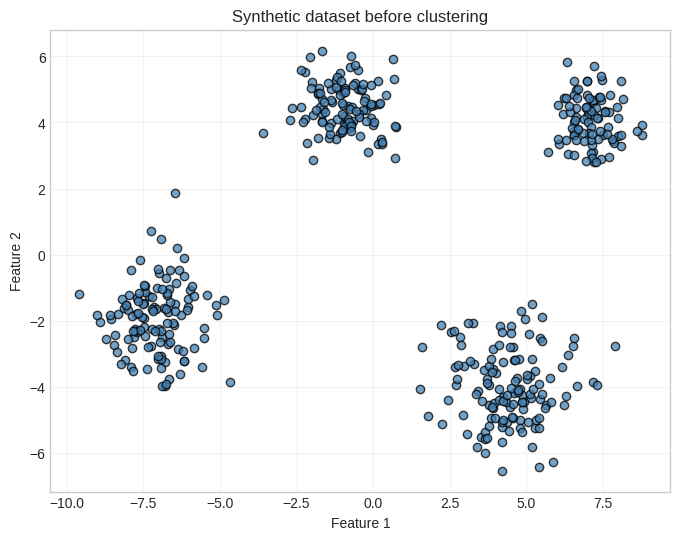

In [40]:
# Take a quick look at the raw data before any clustering
plt.figure(figsize=(8, 6))
plt.scatter(X_syn[:, 0], X_syn[:, 1], color="steelblue", edgecolor="black", alpha=0.75)
plt.title("Synthetic dataset before clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.25)
plt.show()

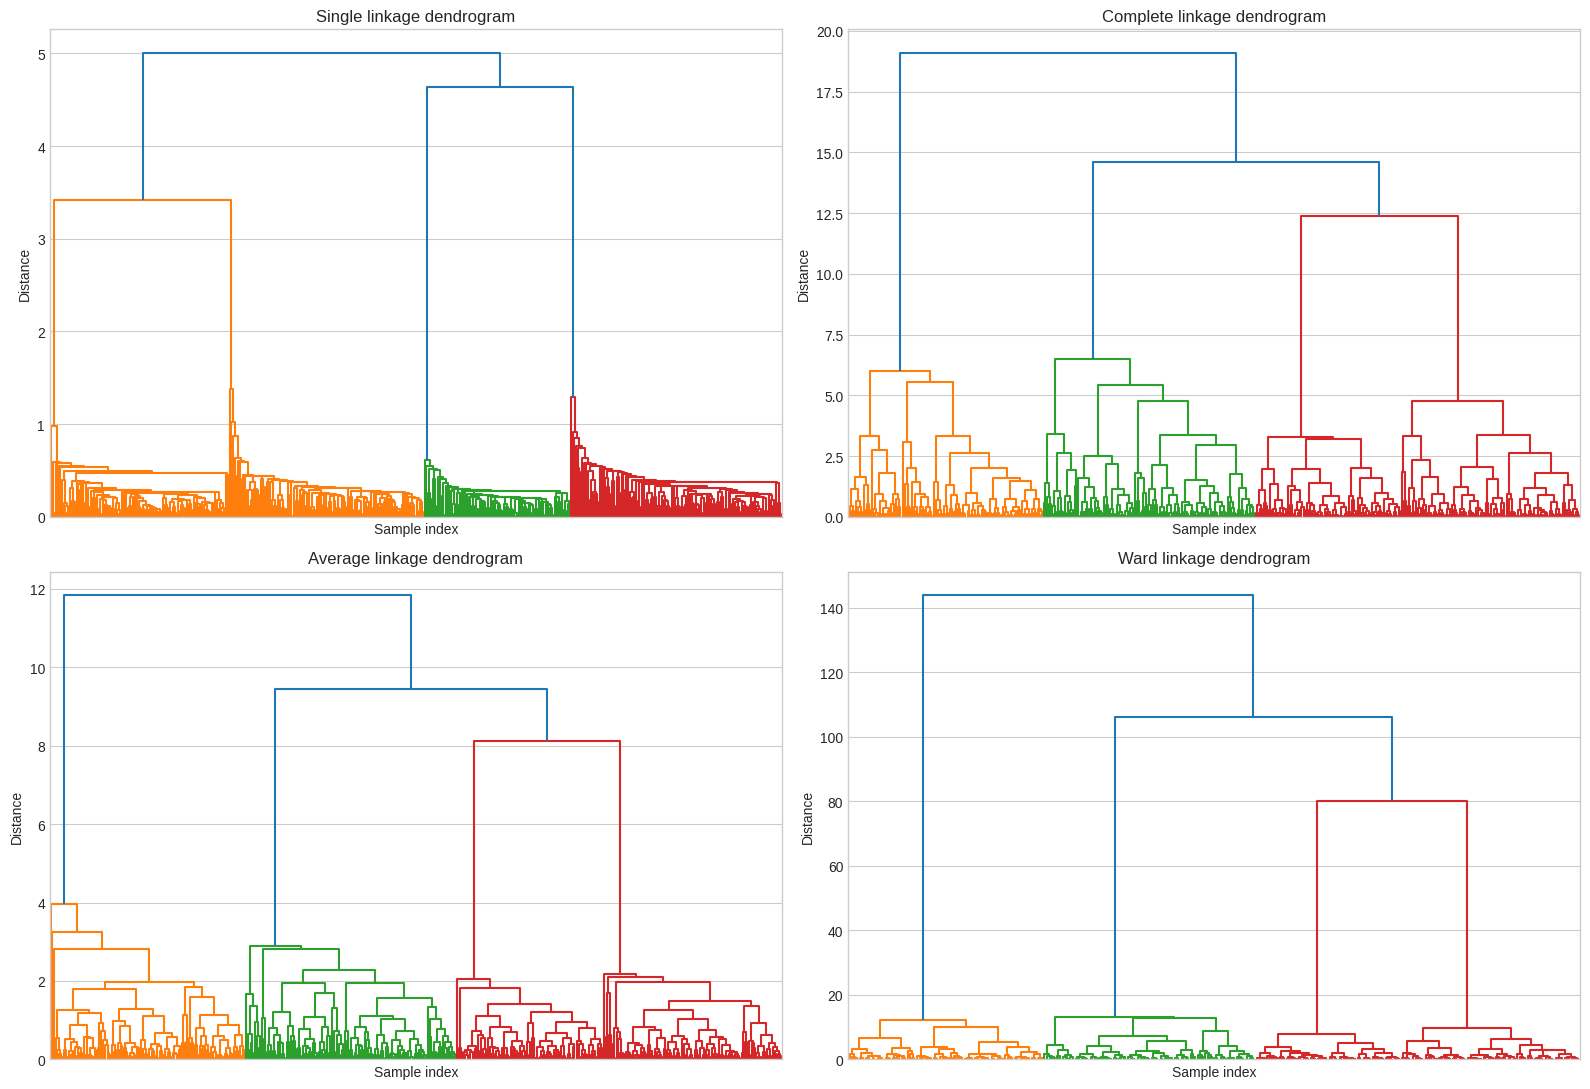

In [41]:
# Explore different ways to connect points in hierarchical clustering
linkage_methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    # Generate the linkage matrix which tracks how clusters merge
    linkage_matrix = linkage(X_syn, method=method)
    # Plot the tree structure (dendrogram)
    dendrogram(linkage_matrix, ax=axis, no_labels=True, color_threshold=None)
    axis.set_title(f"{method.title()} linkage dendrogram")
    axis.set_xlabel("Sample index")
    axis.set_ylabel("Distance")

plt.tight_layout()
plt.show()

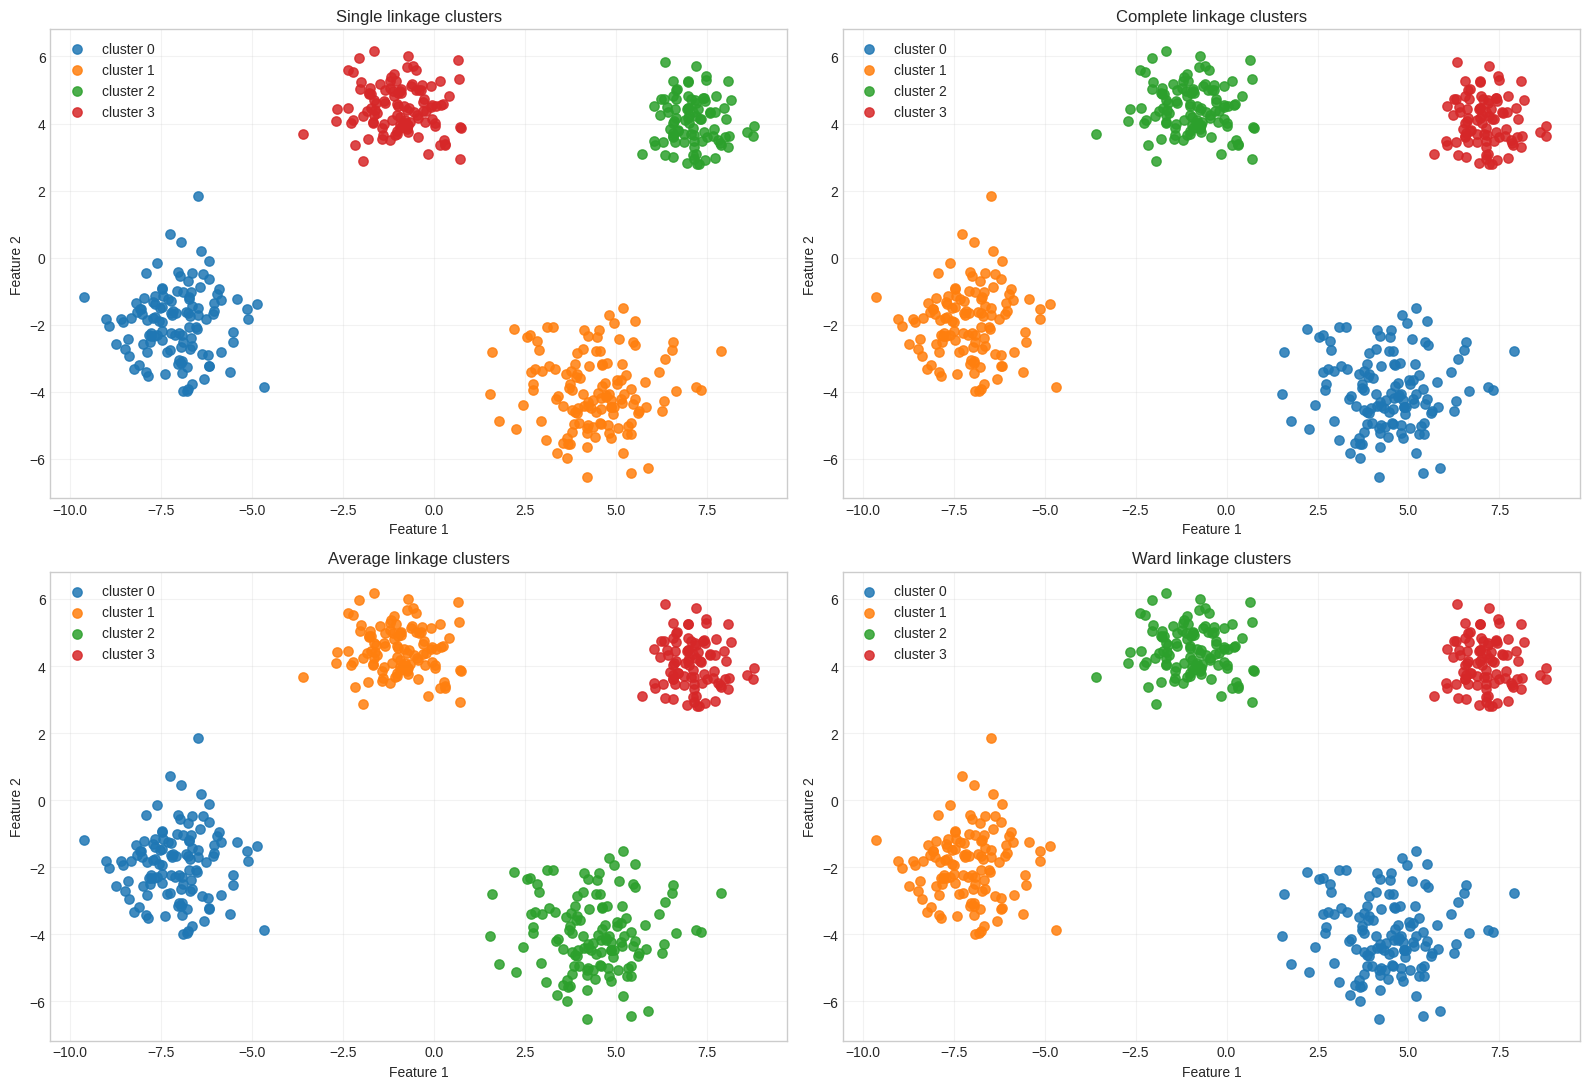

,model,cluster_count,noise_points,silhouette_score
0,Hierarchical - single,4,0,0.8057
1,Hierarchical - complete,4,0,0.8057
2,Hierarchical - average,4,0,0.8057
3,Hierarchical - ward,4,0,0.8057


In [42]:
hierarchical_rows = []
hierarchical_sample_scores = {}
hierarchical_labels = {}

# Now let's actually cut the trees to form 4 clusters
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for axis, method in zip(axes.ravel(), linkage_methods):
    model = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels = model.fit_predict(X_syn)

    hierarchical_labels[method] = labels
    # Visualize the results side-by-side
    plot_cluster_map(X_syn, labels, title=f"{method.title()} linkage clusters", axis=axis, x_label="Feature 1", y_label="Feature 2")

    # Track metrics to compare performance later
    row, sample_scores = describe_clustering(X_syn, labels, model_name=f"Hierarchical - {method}")
    hierarchical_rows.append(row)
    hierarchical_sample_scores[f"{method}_sample_silhouette"] = sample_scores

plt.tight_layout()
plt.show()

# Display the final scorecard for hierarchical methods
hierarchical_results = pd.DataFrame(hierarchical_rows).sort_values(by="silhouette_score", ascending=False)
display(hierarchical_results)

In [43]:
# Inspect the detailed silhouette scores for each point across methods
hierarchical_silhouette_df = pd.DataFrame(hierarchical_sample_scores)
display(hierarchical_silhouette_df.head(10))
display(hierarchical_silhouette_df.describe().T[["mean", "min", "max"]])

,single_sample_silhouette,complete_sample_silhouette,average_sample_silhouette,ward_sample_silhouette
0,0.8697,0.8697,0.8697,0.8697
1,0.8281,0.8281,0.8281,0.8281
2,0.7870,0.7870,0.7870,0.7870
3,0.8651,0.8651,0.8651,0.8651
4,0.8772,0.8772,0.8772,0.8772
5,0.8750,0.8750,0.8750,0.8750
6,0.8497,0.8497,0.8497,0.8497
7,0.5098,0.5098,0.5098,0.5098
8,0.8696,0.8696,0.8696,0.8696
9,0.8265,0.8265,0.8265,0.8265


,mean,min,max
single_sample_silhouette,0.8057,0.3589,0.8936
complete_sample_silhouette,0.8057,0.3589,0.8936
average_sample_silhouette,0.8057,0.3589,0.8936
ward_sample_silhouette,0.8057,0.3589,0.8936


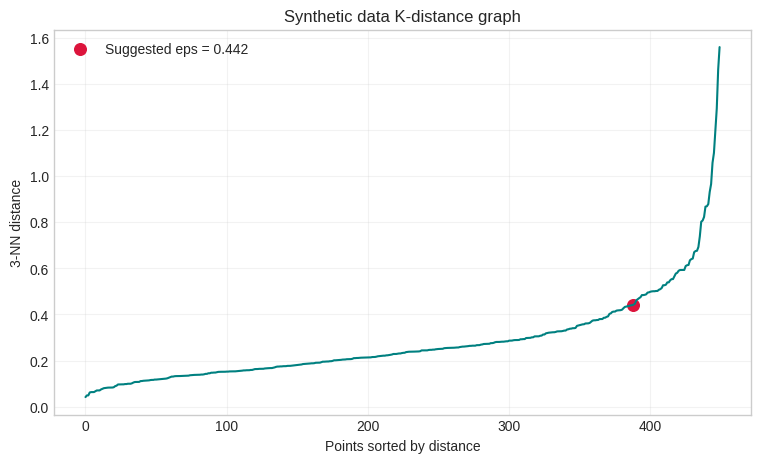

,model,cluster_count,noise_points,silhouette_score,eps
0,DBSCAN eps=0.243,33,169,-0.1590,0.243
1,DBSCAN eps=0.288,23,115,-0.0665,0.288
2,DBSCAN eps=0.332,19,84,0.0580,0.332
3,DBSCAN eps=0.376,15,68,0.0470,0.376
4,DBSCAN eps=0.42,12,47,0.1224,0.420
5,DBSCAN eps=0.464,11,37,0.3147,0.464
6,DBSCAN eps=0.509,6,31,0.5075,0.509
7,DBSCAN eps=0.553,4,24,0.7287,0.553
8,DBSCAN eps=0.597,4,16,0.7491,0.597
9,DBSCAN eps=0.641,4,10,0.7601,0.641


In [44]:
# Switching to DBSCAN: We need to find a good 'eps' (radius) value
min_samples_syn = X_syn.shape[1] + 1

# Calculate distances to nearest neighbors to find the optimal density radius
nn_model_syn = NearestNeighbors(n_neighbors=min_samples_syn)
distances_syn, _ = nn_model_syn.fit(X_syn).kneighbors(X_syn)
k_distances_syn = np.sort(distances_syn[:, -1])

# Use our elbow logic to find the 'knee' in the curve
suggested_eps_syn, elbow_index_syn = estimate_eps_from_k_distance(k_distances_syn)

plt.figure(figsize=(9, 5))
plt.plot(k_distances_syn, color="teal")
plt.scatter(elbow_index_syn, k_distances_syn[elbow_index_syn], color="crimson", s=70, label=f"Suggested eps = {suggested_eps_syn:.3f}")
plt.title("Synthetic data K-distance graph")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples_syn}-NN distance")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Let's test a range of eps values around the suggestion to be sure
eps_candidates_syn = np.unique(np.round(np.linspace(max(0.05, suggested_eps_syn * 0.55), suggested_eps_syn * 1.45, 10), 3))

search_rows_syn = []
for eps in eps_candidates_syn:
    labels = DBSCAN(eps=float(eps), min_samples=min_samples_syn).fit_predict(X_syn)
    row, _ = describe_clustering(X_syn, labels, model_name=f"DBSCAN eps={eps}")
    row["eps"] = float(eps)
    search_rows_syn.append(row)

dbscan_search_syn = pd.DataFrame(search_rows_syn)
display(dbscan_search_syn.sort_values(by="eps"))

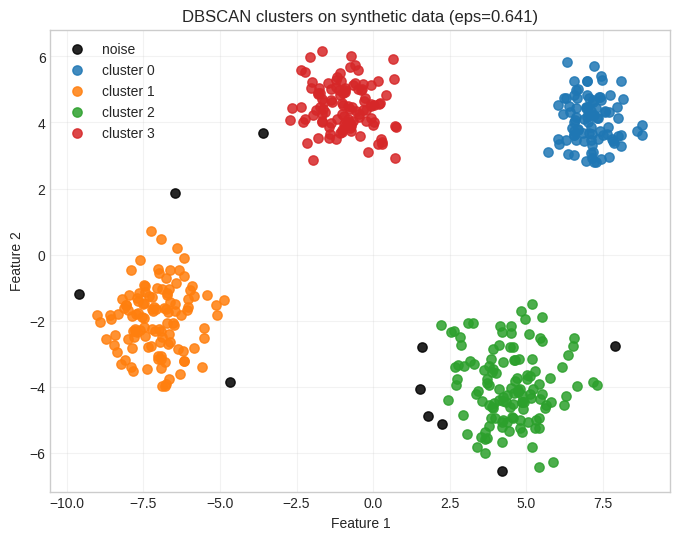

Chosen eps: 0.641
Total noise points found: 10


In [45]:
# Filter out runs that failed to find clusters, then pick the best one
valid_dbscan_syn = dbscan_search_syn.dropna(subset=["silhouette_score"]).copy()
valid_dbscan_syn = valid_dbscan_syn[valid_dbscan_syn["cluster_count"] >= 2].copy()

best_dbscan_syn = valid_dbscan_syn.sort_values(by=["silhouette_score", "noise_points"], ascending=[False, True]).iloc[0]

# Run the final model with our winner
best_eps_syn = float(best_dbscan_syn["eps"])
dbscan_syn = DBSCAN(eps=best_eps_syn, min_samples=min_samples_syn)
dbscan_syn_labels = dbscan_syn.fit_predict(X_syn)

# Log and visualize the DBSCAN results
dbscan_syn_row, dbscan_syn_sample_scores = describe_clustering(X_syn, dbscan_syn_labels, model_name=f"DBSCAN (eps={best_eps_syn:.3f}, min_samples={min_samples_syn})")

plt.figure(figsize=(8, 6))
plot_cluster_map(X_syn, dbscan_syn_labels, title=f"DBSCAN clusters on synthetic data (eps={best_eps_syn:.3f})", x_label="Feature 1", y_label="Feature 2")
plt.show()

print("Chosen eps:", round(best_eps_syn, 3))
print("Total noise points found:", dbscan_syn_row["noise_points"])

In [46]:
# Compare hierarchical methods against the best DBSCAN model
synthetic_comparison = pd.concat(
    [hierarchical_results, pd.DataFrame([dbscan_syn_row])],
    ignore_index=True
).sort_values(by="silhouette_score", ascending=False)

display(synthetic_comparison)

,model,cluster_count,noise_points,silhouette_score
0,Hierarchical - single,4,0,0.8057
1,Hierarchical - complete,4,0,0.8057
2,Hierarchical - average,4,0,0.8057
3,Hierarchical - ward,4,0,0.8057
4,"DBSCAN (eps=0.641, min_samples=3)",4,10,0.7601


In [47]:
from sklearn.datasets import load_iris

# Load the classic Iris dataset for a real-world test
iris_bundle = load_iris(as_frame=True)
iris_features = iris_bundle.data.copy()
iris_target = iris_bundle.target.copy()
iris_names = iris_bundle.target_names

# Scale the data (crucial for distance-based clustering)
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(iris_features)

# Use PCA to squash 4D data into 2D so we can plot it easily
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

print("Original Iris feature shape:", iris_features.shape)
display(iris_features.head())

Original Iris feature shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


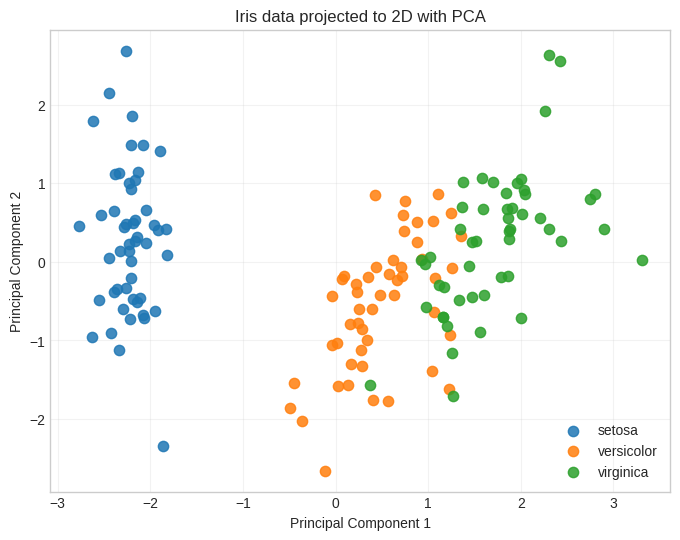

In [48]:
# Plot the ground truth classes using our PCA projection
plt.figure(figsize=(8, 6))
for class_id, class_name in enumerate(iris_names):
    mask = iris_target.to_numpy() == class_id
    plt.scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1], s=55, alpha=0.85, label=class_name)

plt.title("Iris data projected to 2D with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

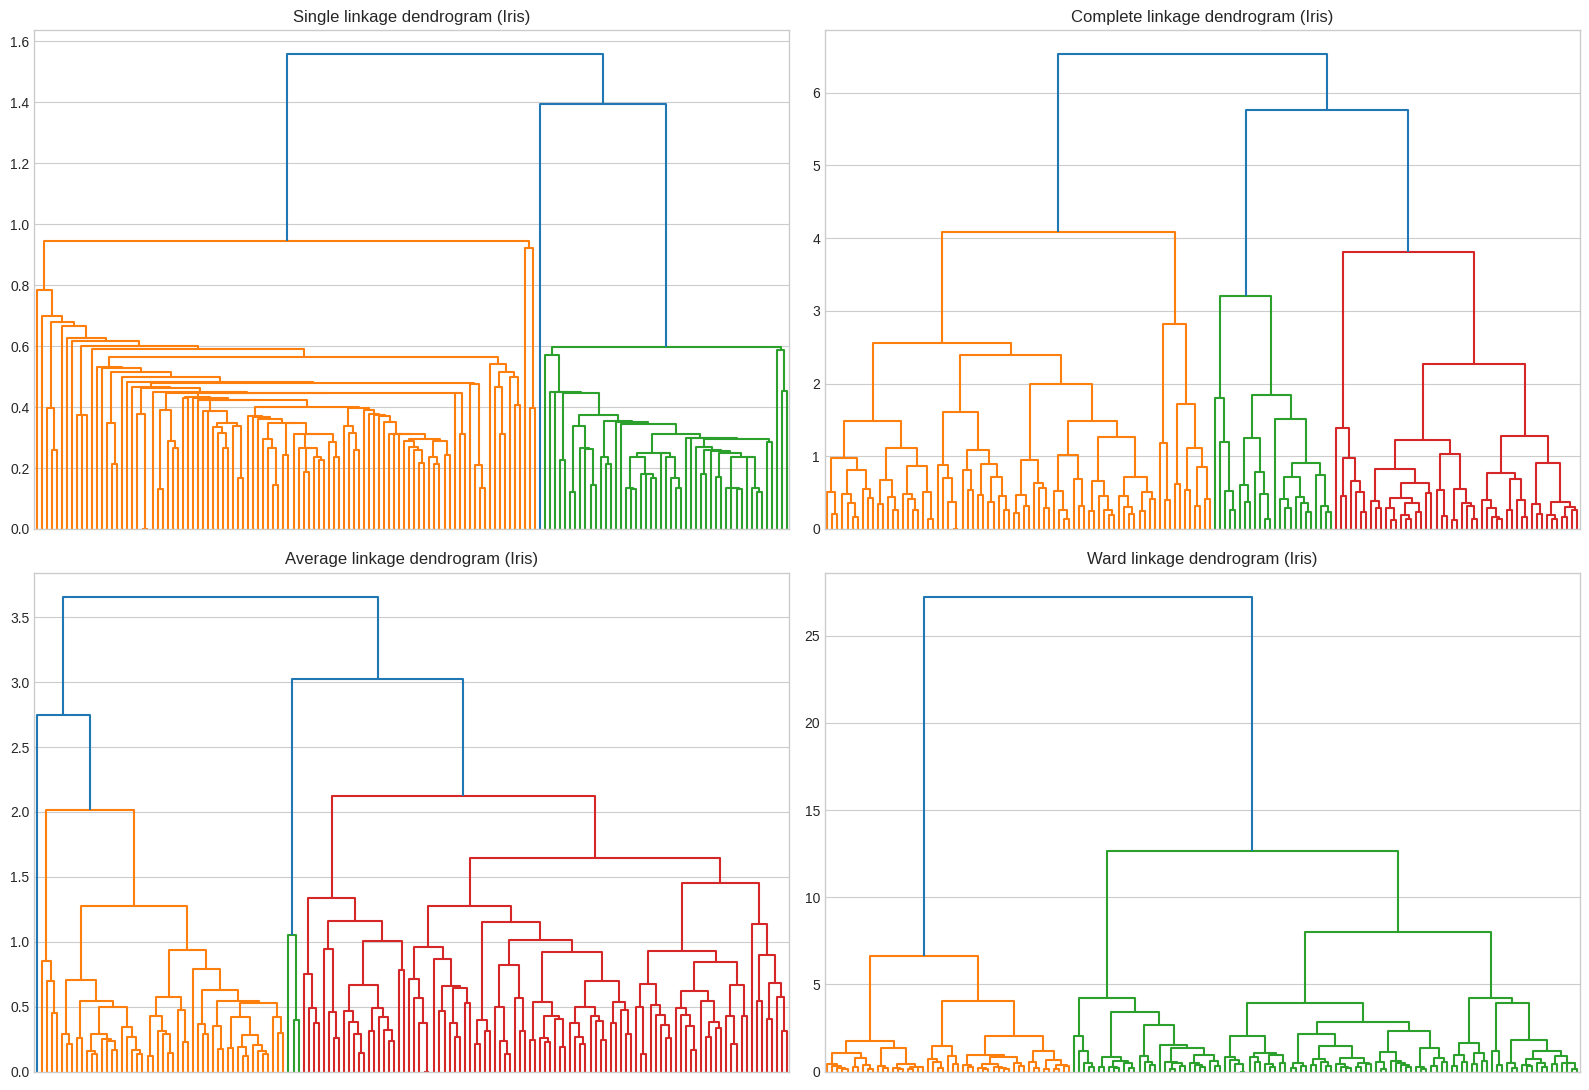

In [49]:
# Run hierarchical linkage again, this time on the real Iris data
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for axis, method in zip(axes.ravel(), linkage_methods):
    linkage_matrix = linkage(X_iris_scaled, method=method)
    dendrogram(linkage_matrix, ax=axis, no_labels=True, color_threshold=None)
    axis.set_title(f"{method.title()} linkage dendrogram (Iris)")

plt.tight_layout()
plt.show()

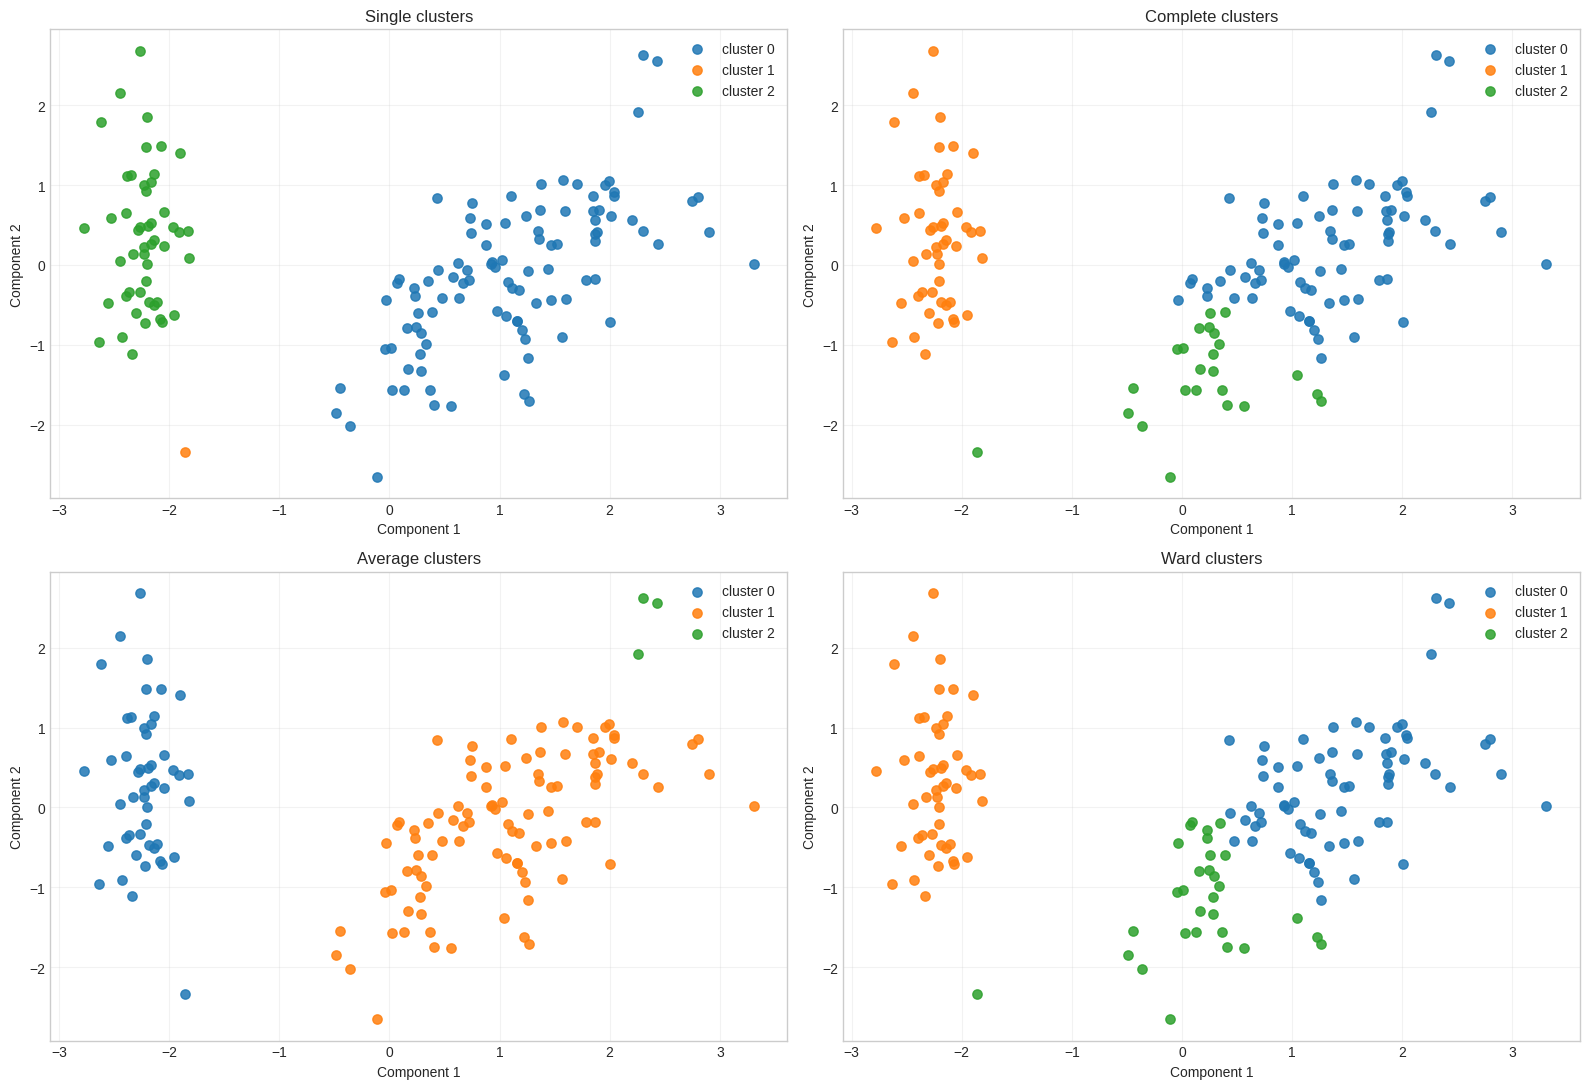

,model,cluster_count,noise_points,silhouette_score
0,Hierarchical - single,3,0,0.5046
2,Hierarchical - average,3,0,0.4803
1,Hierarchical - complete,3,0,0.4496
3,Hierarchical - ward,3,0,0.4467


In [50]:
hierarchical_rows_iris = []
hierarchical_sample_scores_iris = {}

# Group Iris data into 3 clusters (since we know there are 3 species)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for axis, method in zip(axes.ravel(), linkage_methods):
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X_iris_scaled)

    plot_cluster_map(X_iris_pca, labels, title=f"{method.title()} clusters", axis=axis)

    row, scores = describe_clustering(X_iris_scaled, labels, f"Hierarchical - {method}")
    hierarchical_rows_iris.append(row)
    hierarchical_sample_scores_iris[f"{method}_sample_silhouette"] = scores

plt.tight_layout()
plt.show()
display(pd.DataFrame(hierarchical_rows_iris).sort_values("silhouette_score", ascending=False))

In [51]:
# Show statistical breakdown of how happy each sample is in its cluster for Iris
hierarchical_silhouette_df_iris = pd.DataFrame(hierarchical_sample_scores_iris)
display(hierarchical_silhouette_df_iris.describe().T[["mean", "min", "max"]])

,mean,min,max
single_sample_silhouette,0.5046,-0.3825,0.7153
complete_sample_silhouette,0.4496,-0.2989,0.7438
average_sample_silhouette,0.4803,-0.2350,0.7945
ward_sample_silhouette,0.4467,-0.2304,0.7340


In [52]:
# Tuning DBSCAN for Iris
min_samples_iris = X_iris_scaled.shape[1] + 1
nn_model_iris = NearestNeighbors(n_neighbors=min_samples_iris)
distances_iris, _ = nn_model_iris.fit(X_iris_scaled).kneighbors(X_iris_scaled)
k_distances_iris = np.sort(distances_iris[:, -1])

suggested_eps_iris, _ = estimate_eps_from_k_distance(k_distances_iris)

# Grid search for the best radius on Iris
eps_candidates_iris = np.unique(np.round(np.linspace(max(0.1, suggested_eps_iris * 0.55), suggested_eps_iris * 1.45, 10), 3))
search_rows_iris = []
for eps in eps_candidates_iris:
    labels = DBSCAN(eps=float(eps), min_samples=min_samples_iris).fit_predict(X_iris_scaled)
    row, _ = describe_clustering(X_iris_scaled, labels, f"DBSCAN eps={eps}")
    row["eps"] = float(eps)
    search_rows_iris.append(row)

display(pd.DataFrame(search_rows_iris).sort_values("eps"))

,model,cluster_count,noise_points,silhouette_score,eps
0,DBSCAN eps=0.416,5,63,0.0619,0.416
1,DBSCAN eps=0.492,2,36,0.3419,0.492
2,DBSCAN eps=0.568,2,29,0.3880,0.568
3,DBSCAN eps=0.643,2,15,0.4741,0.643
4,DBSCAN eps=0.719,2,6,0.5234,0.719
5,DBSCAN eps=0.795,2,4,0.5217,0.795
6,DBSCAN eps=0.87,2,4,0.5217,0.870
7,DBSCAN eps=0.946,2,4,0.5217,0.946
8,DBSCAN eps=1.022,2,3,0.5383,1.022
9,DBSCAN eps=1.097,2,2,0.5518,1.097


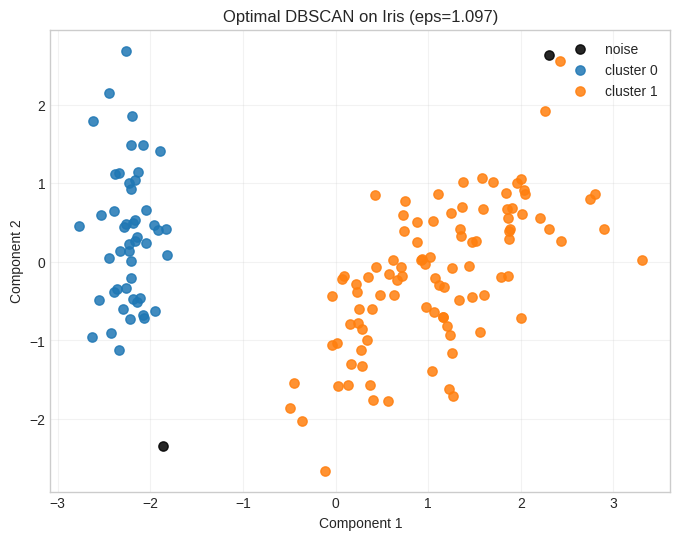

In [53]:
# Select and plot the best DBSCAN configuration for Iris
valid_dbscan_iris = pd.DataFrame(search_rows_iris).query("cluster_count >= 2").dropna()
best_dbscan_iris = valid_dbscan_iris.sort_values(["silhouette_score", "noise_points"], ascending=[False, True]).iloc[0]

best_eps_iris = float(best_dbscan_iris["eps"])
dbscan_iris_labels = DBSCAN(eps=best_eps_iris, min_samples=min_samples_iris).fit_predict(X_iris_scaled)

plt.figure(figsize=(8, 6))
plot_cluster_map(X_iris_pca, dbscan_iris_labels, title=f"Optimal DBSCAN on Iris (eps={best_eps_iris:.3f})")
plt.show()

In [54]:
# Final ranking: How did hierarchical clustering compare to DBSCAN on the Iris dataset?
iris_comparison = pd.concat(
    [pd.DataFrame(hierarchical_rows_iris), pd.DataFrame([describe_clustering(X_iris_scaled, dbscan_iris_labels, f"DBSCAN (eps={best_eps_iris:.3f})")[0]])],
    ignore_index=True
).sort_values("silhouette_score", ascending=False)

display(iris_comparison)

,model,cluster_count,noise_points,silhouette_score
4,DBSCAN (eps=1.097),2,2,0.5518
0,Hierarchical - single,3,0,0.5046
2,Hierarchical - average,3,0,0.4803
1,Hierarchical - complete,3,0,0.4496
3,Hierarchical - ward,3,0,0.4467
